# 07 — Bid Optimization (SP3)

**Task 2.4**: First-price bid shading using debiased pCTR (ESCM2-WC(DR)) and Kaplan-Meier market price CDF.

## Key Results

| Strategy | Win Rate | Clicks | Total Surplus | Avg CPC | Overpayment | ROI |
|----------|----------|--------|---------------|---------|-------------|-----|
| ipinyou_flat | 100% | 4,482 | -805M | 271K | 10.14 | 0.74 |
| truthful | 51.8% | 2,266 | 17.7M | 128K | 5.79 | 1.56 |
| linear_08 | 45.1% | 1,980 | 63.7M | 108K | 5.25 | 1.84 |
| linear_06 | 37.1% | 1,702 | 100.1M | 83.9K | 4.58 | 2.38 |
| optimal_km | 33.2% | 1,480 | 119.0M | 59.5K | 3.44 | 3.36 |
| optimal_exchange | 33.7% | 1,486 | 120.8M | 61.7K | 3.38 | 3.24 |
| dual_regime | 37.9% | 1,608 | 127.7M | 61.3K | 2.77 | 3.26 |

**Core insight**: iPinYou flat-bid strategy (277/294 CPM) → massive overbidding (surplus -805M).
Optimal shading recovers +128M surplus while maintaining competitive click acquisition.

**Pipeline**: SP1 (debiased pCTR) → SP2 (market price CDF) → **SP3 (bid optimization)**

## Section 0: Setup & Data Loading

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Project setup
PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_PATH = PROJECT_ROOT / 'results'
FIG_PATH = RESULTS_PATH / 'figures'
DATA_PATH = PROJECT_ROOT / 'data' / 'ipinyou' / 'prediction' / 'features'
CDF_PATH = RESULTS_PATH / 'market_price_cdf'
BIDDING_PATH = RESULTS_PATH / 'bidding'

FIG_PATH.mkdir(parents=True, exist_ok=True)
BIDDING_PATH.mkdir(parents=True, exist_ok=True)

# Plotting defaults
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = sns.color_palette('Set2', 8)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figure path: {FIG_PATH}")

Project root: /Users/taehyun/project/rtb_ipinyou
Figure path: /Users/taehyun/project/rtb_ipinyou/results/figures


In [2]:
# --- Load test parquet (only needed columns) ---
COLS_NEEDED = ['bidprice', 'payprice', 'slotprice', 'adexchange', 'hour', 'win', 'click', 'advertiser']
test_df = pd.read_parquet(DATA_PATH / 'test.parquet', columns=COLS_NEEDED)
print(f"Test set: {len(test_df):,} rows")
print(f"Columns: {list(test_df.columns)}")

# --- Load ESCM2-DR predictions ---
preds = dict(np.load(RESULTS_PATH / 'models' / 'escm2wc_dr_test_predictions.npz'))
print(f"\nPrediction keys: {list(preds.keys())}")
print(f"p_ctr shape: {preds['p_ctr'].shape}")
print(f"y_win sum: {preds['y_win'].sum():,} (won impressions)")

# --- Load KM CDFs ---
from src.bidding.shading import load_market_cdf, load_exchange_cdfs

overall_cdf = load_market_cdf(str(CDF_PATH / 'km_cdf_overall.npz'))
exchange_cdfs = load_exchange_cdfs(str(CDF_PATH))

print(f"\nOverall CDF: {len(overall_cdf.price_grid)} grid points, F(300)={overall_cdf.cdf[-1]:.4f}")
print(f"Exchange CDFs loaded: {list(exchange_cdfs.keys())}")
for ex_id, cdf in exchange_cdfs.items():
    print(f"  Exchange {ex_id}: F(300)={cdf.cdf[-1]:.4f}, median={cdf.median_price}")

Test set: 19,424,025 rows
Columns: ['bidprice', 'payprice', 'slotprice', 'adexchange', 'hour', 'win', 'click', 'advertiser']

Prediction keys: ['p_win', 'p_ctr', 'p_click_bid', 'y_win', 'y_click']
p_ctr shape: (19424025,)
y_win sum: 4,234,318 (won impressions)

Overall CDF: 1000 grid points, F(300)=0.2134
Exchange CDFs loaded: ['1', '2', '3']
  Exchange 1: F(300)=0.6894, median=153.0
  Exchange 2: F(300)=0.2915, median=inf
  Exchange 3: F(300)=0.1195, median=inf


In [3]:
# --- Prepare won-only data ---
from src.bidding.simulator import prepare_won_only_data
from src.bidding.value import compute_impression_values, ValueConfig

won_data = prepare_won_only_data(test_df, preds)
print(f"Won-only impressions: {won_data['n_total']:,}")
print(f"Filtered (lost/no payprice): {won_data['n_filtered']:,}")

# Compute V(x) = pCTR x CPC_target (200,000 CPM/click)
val_config = ValueConfig(goal_type="CPC", cpc_target=200_000.0)
val_result = compute_impression_values(won_data['p_ctr'], val_config)
values = val_result.values

print(f"\nV(x) statistics:")
print(f"  Mean:   {val_result.mean_value:.1f} CPM")
print(f"  Median: {val_result.median_value:.1f} CPM")
print(f"  Std:    {val_result.std_value:.1f} CPM")
print(f"  %% above market median (68): {val_result.pct_above_market_median:.1%}")

print(f"\nMarket price statistics:")
mp = won_data['market_prices']
print(f"  Mean:   {mp.mean():.2f}")
print(f"  Median: {np.median(mp):.1f}")
print(f"  P90:    {np.percentile(mp, 90):.1f}")

Won-only impressions: 4,228,166
Filtered (lost/no payprice): 15,195,859

V(x) statistics:
  Mean:   96.9 CPM
  Median: 73.1 CPM
  Std:    96.3 CPM
  %% above market median (68): 52.6%

Market price statistics:
  Mean:   86.51
  Median: 61.0
  P90:    201.0


## Section 1: Value Distribution Analysis

V(x) = debiased_pCTR(x) x CPC_target (200,000 CPM/click).
The distribution of impression values relative to market prices determines bid shading opportunity.

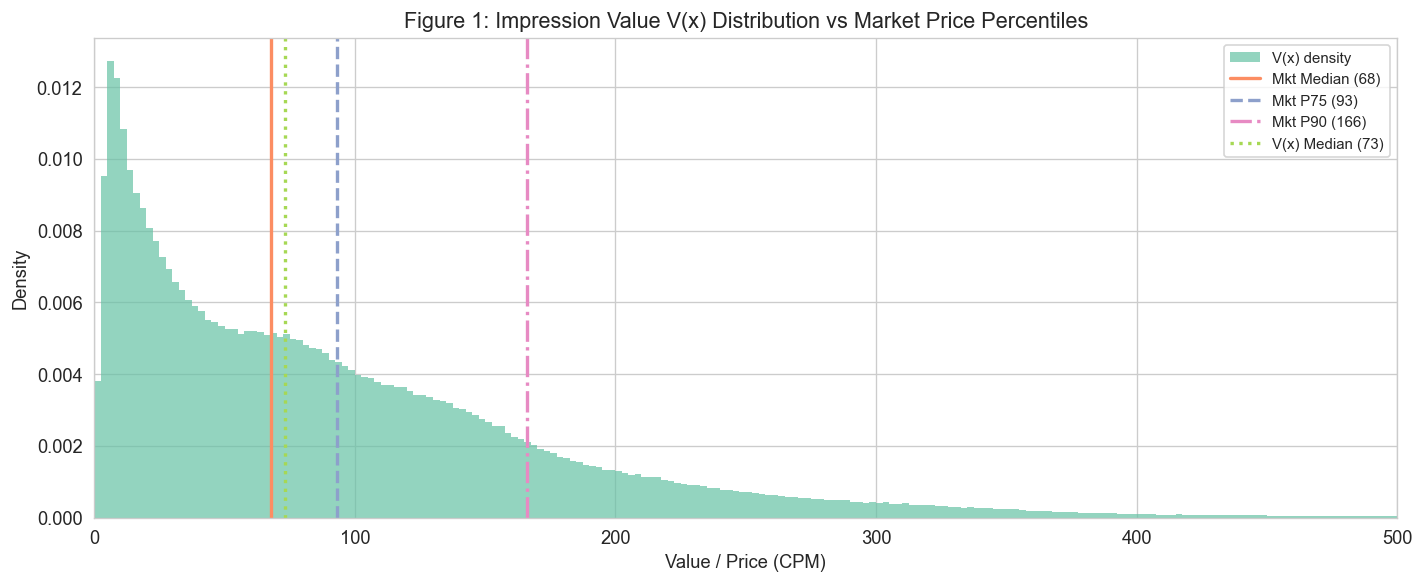

V(x) > market median: 52.6%
V(x) > market P90 (166): 16.8%


In [4]:
# Figure 1: V(x) distribution with market price percentiles
fig, ax = plt.subplots(figsize=(12, 5))

# V(x) histogram
ax.hist(values, bins=200, range=(0, 500), density=True, alpha=0.7,
        color=PALETTE[0], edgecolor='none', label='V(x) density')

# Market price percentiles (vertical lines)
market_lines = [
    (68, 'Mkt Median (68)', PALETTE[1], '-'),
    (93, 'Mkt P75 (93)', PALETTE[2], '--'),
    (166, 'Mkt P90 (166)', PALETTE[3], '-.'),
]
for price, label, color, ls in market_lines:
    ax.axvline(price, color=color, linestyle=ls, linewidth=2, label=label)

# V(x) median
ax.axvline(val_result.median_value, color=PALETTE[4], linestyle=':',
           linewidth=2, label=f'V(x) Median ({val_result.median_value:.0f})')

ax.set_xlabel('Value / Price (CPM)')
ax.set_ylabel('Density')
ax.set_title('Figure 1: Impression Value V(x) Distribution vs Market Price Percentiles')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 500)

fig.tight_layout()
fig.savefig(FIG_PATH / '07_value_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"V(x) > market median: {val_result.pct_above_market_median:.1%}")
print(f"V(x) > market P90 (166): {np.mean(values > 166):.1%}")

## Section 2: Bid Shading Theory & Visualization

**Core formula**: b* = argmax_b (V - b) x F(b)

- F(b) = KM CDF (probability of winning at bid b)
- Surplus = (V - b) x F(b): trade-off between margin and win probability
- Optimal shading: shade more when V >> market price, shade less when V is marginal

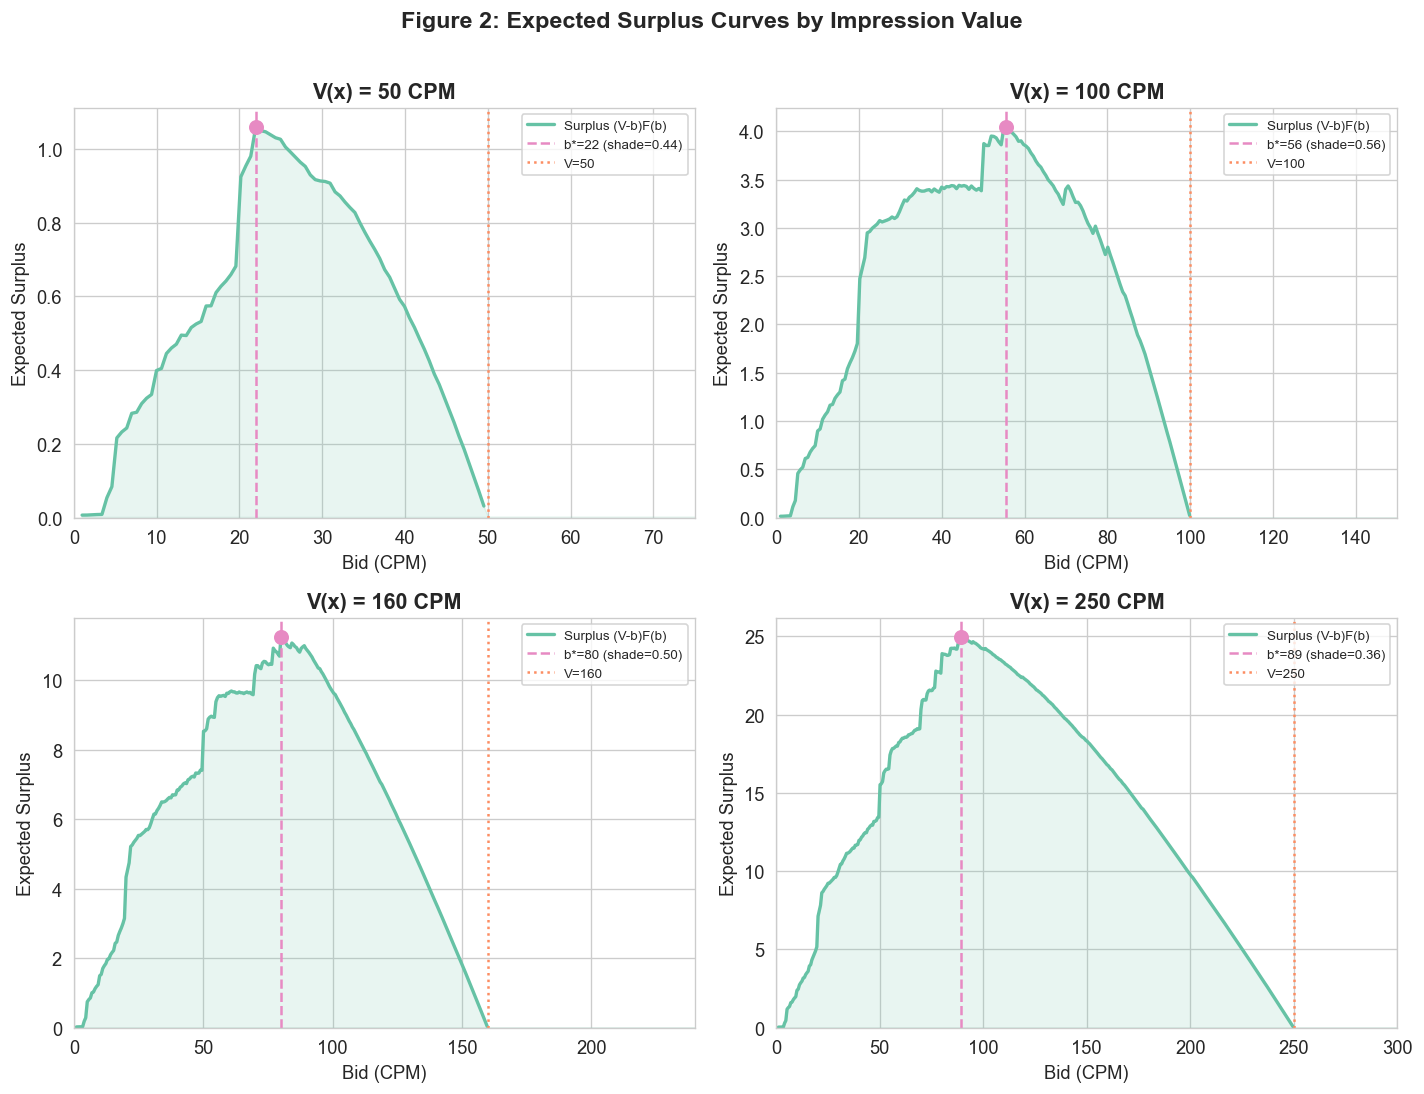

In [5]:
# Compute surplus curves for representative V values
from src.bidding.shading import _interpolate_cdf

V_examples = [50, 100, 160, 250]
bid_range = np.linspace(1, 300, 500)
cdf_values = _interpolate_cdf(bid_range, overall_cdf)

# Figure 2: 4-panel surplus curves
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes_flat = axes.flatten()

for idx, (V_ex, ax) in enumerate(zip(V_examples, axes_flat)):
    margin = V_ex - bid_range
    surplus = margin * cdf_values
    surplus = np.where(margin > 0, surplus, np.nan)

    ax.plot(bid_range, surplus, color=PALETTE[0], linewidth=2, label='Surplus (V-b)F(b)')
    ax.fill_between(bid_range, 0, np.nan_to_num(surplus, 0), alpha=0.15, color=PALETTE[0])

    # Optimal bid
    valid_mask = bid_range < V_ex
    if valid_mask.any():
        surplus_valid = np.nan_to_num(surplus, -np.inf)
        best_idx = np.argmax(surplus_valid)
        b_star = bid_range[best_idx]
        s_star = surplus_valid[best_idx]
        ax.axvline(b_star, color=PALETTE[3], linestyle='--', linewidth=1.5,
                   label=f'b*={b_star:.0f} (shade={b_star/V_ex:.2f})')
        ax.plot(b_star, s_star, 'o', color=PALETTE[3], markersize=8, zorder=5)

    # V line
    ax.axvline(V_ex, color=PALETTE[1], linestyle=':', linewidth=1.5, label=f'V={V_ex}')

    ax.set_title(f'V(x) = {V_ex} CPM', fontweight='bold')
    ax.set_xlabel('Bid (CPM)')
    ax.set_ylabel('Expected Surplus')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_xlim(0, min(V_ex * 1.5, 300))
    ax.set_ylim(bottom=0)

fig.suptitle('Figure 2: Expected Surplus Curves by Impression Value', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIG_PATH / '07_surplus_curves.png', dpi=150, bbox_inches='tight')
plt.show()

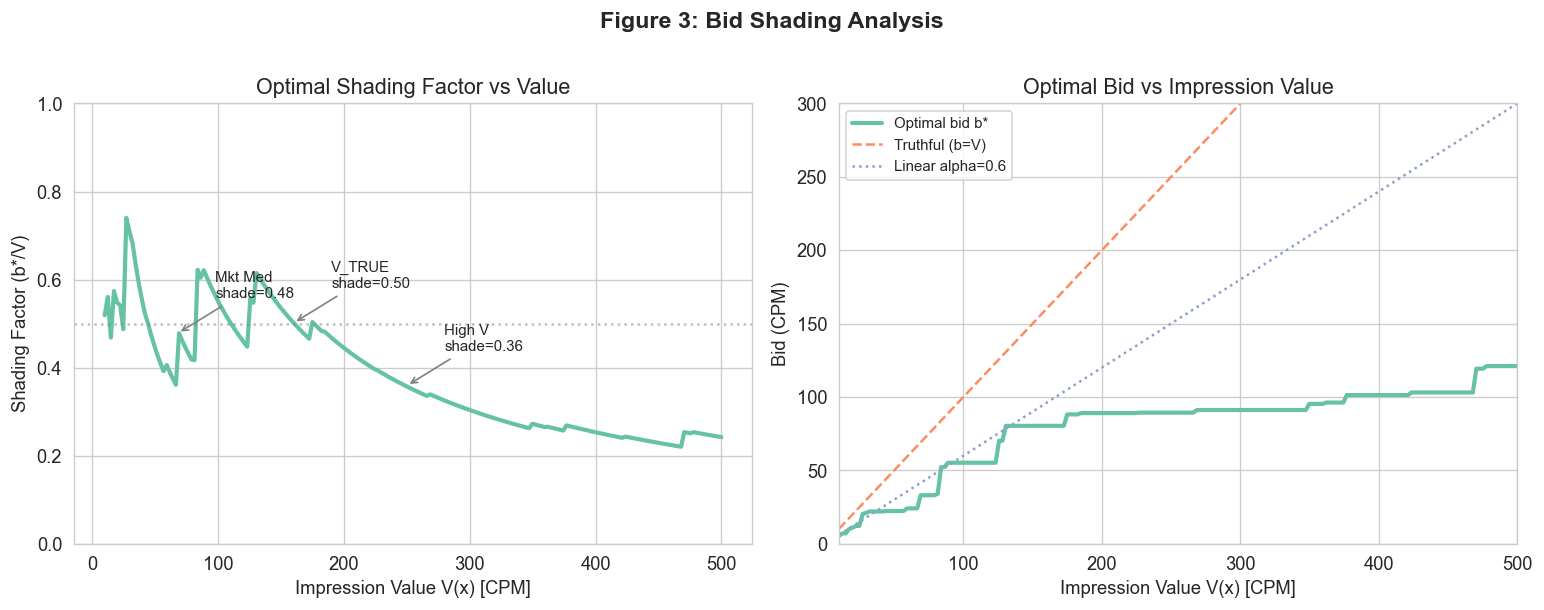

Note: KM CDF max F(300) = 0.213 (heavy right-censoring).
This means the CDF never reaches 1.0 — many market prices > 300 CPM.
Shading factor stays relatively flat because win probability plateaus early.


In [6]:
# Figure 3: Shading factor (b*/V) as function of V
from src.bidding.shading import optimal_bid_vectorized

V_range = np.linspace(10, 500, 200)
opt_bids_range, opt_surplus_range = optimal_bid_vectorized(V_range, overall_cdf)
shading_factors = opt_bids_range / V_range

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Shading factor vs V
ax1.plot(V_range, shading_factors, color=PALETTE[0], linewidth=2.5)
ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax1.set_xlabel('Impression Value V(x) [CPM]')
ax1.set_ylabel('Shading Factor (b*/V)')
ax1.set_title('Optimal Shading Factor vs Value')
ax1.set_ylim(0, 1.0)
# Annotate key V points
for V_pt, label in [(68, 'Mkt Med'), (160, 'V_TRUE'), (250, 'High V')]:
    idx = np.argmin(np.abs(V_range - V_pt))
    ax1.annotate(f'{label}\nshade={shading_factors[idx]:.2f}',
                 xy=(V_pt, shading_factors[idx]),
                 xytext=(V_pt + 30, shading_factors[idx] + 0.08),
                 arrowprops=dict(arrowstyle='->', color='gray'),
                 fontsize=9)

# Right: Optimal bid vs V (with truthful reference)
ax2.plot(V_range, opt_bids_range, color=PALETTE[0], linewidth=2.5, label='Optimal bid b*')
ax2.plot(V_range, V_range, color=PALETTE[1], linestyle='--', linewidth=1.5, label='Truthful (b=V)')
ax2.plot(V_range, V_range * 0.6, color=PALETTE[2], linestyle=':', linewidth=1.5, label='Linear alpha=0.6')
ax2.set_xlabel('Impression Value V(x) [CPM]')
ax2.set_ylabel('Bid (CPM)')
ax2.set_title('Optimal Bid vs Impression Value')
ax2.legend(fontsize=9)
ax2.set_xlim(10, 500)
ax2.set_ylim(0, 300)

fig.suptitle('Figure 3: Bid Shading Analysis', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIG_PATH / '07_shading_factor.png', dpi=150, bbox_inches='tight')
plt.show()

print("Note: KM CDF max F(300) = {:.3f} (heavy right-censoring).".format(overall_cdf.cdf[-1]))
print("This means the CDF never reaches 1.0 — many market prices > 300 CPM.")
print("Shading factor stays relatively flat because win probability plateaus early.")

## Section 3: Exchange-Conditional Shading

Different ad exchanges exhibit dramatically different competition levels:
- Exchange 1: F(300) = 0.69 (low competition, median 153)
- Exchange 2: F(300) = 0.29 (moderate competition)
- Exchange 3: F(300) = 0.12 (high competition)

Exchange-conditional shading adapts bids to local market conditions.

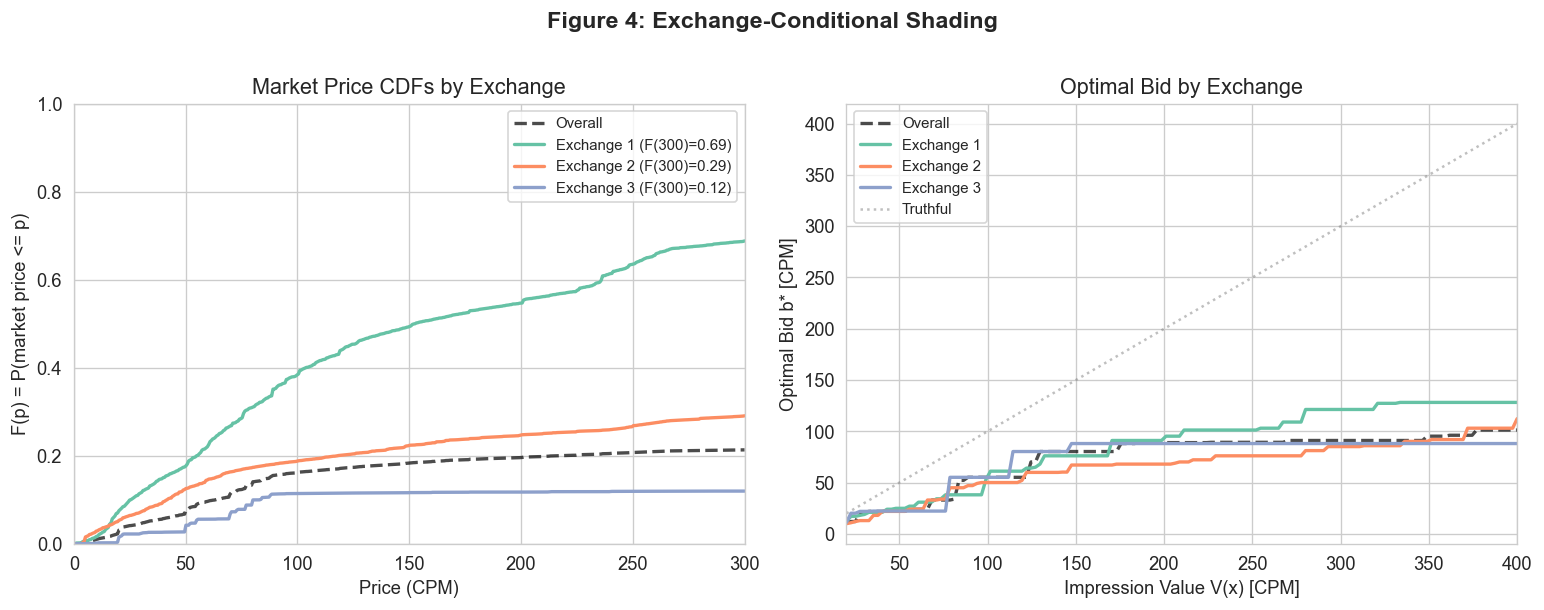

Exchange bid comparison at V=160 CPM:
  Exchange 1: b*=76.1, shade=0.476
  Exchange 2: b*=67.1, shade=0.420
  Exchange 3: b*=88.1, shade=0.551
  Overall:    b*=80.3, shade=0.502


In [7]:
# Figure 4: Exchange CDF comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors_ex = [PALETTE[0], PALETTE[1], PALETTE[2]]
price_grid = np.linspace(1, 300, 500)

# Left: CDFs
ax1.plot(price_grid, _interpolate_cdf(price_grid, overall_cdf),
         color='black', linewidth=2, linestyle='--', label='Overall', alpha=0.7)
for i, (ex_id, cdf) in enumerate(sorted(exchange_cdfs.items())):
    cdf_vals = _interpolate_cdf(price_grid, cdf)
    ax1.plot(price_grid, cdf_vals, color=colors_ex[i], linewidth=2,
             label=f'Exchange {ex_id} (F(300)={cdf.cdf[-1]:.2f})')

ax1.set_xlabel('Price (CPM)')
ax1.set_ylabel('F(p) = P(market price <= p)')
ax1.set_title('Market Price CDFs by Exchange')
ax1.legend(fontsize=9)
ax1.set_xlim(0, 300)
ax1.set_ylim(0, 1.0)

# Right: Optimal bid by exchange for same V range
V_test = np.linspace(20, 400, 150)
ax2.plot(*zip(*[(v, optimal_bid_vectorized(np.array([v]), overall_cdf)[0][0])
                for v in V_test]),
         color='black', linestyle='--', linewidth=2, label='Overall', alpha=0.7)

for i, (ex_id, cdf) in enumerate(sorted(exchange_cdfs.items())):
    bids_ex = [optimal_bid_vectorized(np.array([v]), cdf)[0][0] for v in V_test]
    ax2.plot(V_test, bids_ex, color=colors_ex[i], linewidth=2,
             label=f'Exchange {ex_id}')

ax2.plot(V_test, V_test, color='gray', linestyle=':', alpha=0.5, label='Truthful')
ax2.set_xlabel('Impression Value V(x) [CPM]')
ax2.set_ylabel('Optimal Bid b* [CPM]')
ax2.set_title('Optimal Bid by Exchange')
ax2.legend(fontsize=9)
ax2.set_xlim(20, 400)

fig.suptitle('Figure 4: Exchange-Conditional Shading', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIG_PATH / '07_exchange_shading.png', dpi=150, bbox_inches='tight')
plt.show()

# Exchange heterogeneity summary
print("Exchange bid comparison at V=160 CPM:")
for ex_id, cdf in sorted(exchange_cdfs.items()):
    b_star = optimal_bid_vectorized(np.array([160.0]), cdf)[0][0]
    print(f"  Exchange {ex_id}: b*={b_star:.1f}, shade={b_star/160:.3f}")
b_overall = optimal_bid_vectorized(np.array([160.0]), overall_cdf)[0][0]
print(f"  Overall:    b*={b_overall:.1f}, shade={b_overall/160:.3f}")

## Section 4: Dual-Regime Shading

iPinYou EDA finding: ~32% of won bids have payprice near floor price (floor-binding).
Dual-regime strategy:
- **Floor-bound regime**: market price dictated by floor → bid slightly above floor (1.05x)
- **Competitive regime**: standard optimal shading using KM CDF

In [8]:
# Floor-binding detection
slotprice = won_data['slotprice']
is_floor_bound = (slotprice > 0) & (slotprice > values * 0.1)

n_floor = is_floor_bound.sum()
n_competitive = (~is_floor_bound).sum()
print(f"Dual-regime classification:")
print(f"  Floor-bound:  {n_floor:>10,} ({n_floor/len(values):.1%})")
print(f"  Competitive:  {n_competitive:>10,} ({n_competitive/len(values):.1%})")
print(f"  Total:        {len(values):>10,}")

# Market price stats by regime
print(f"\nMarket price by regime:")
print(f"  Floor-bound:  mean={mp[is_floor_bound].mean():.1f}, "
      f"median={np.median(mp[is_floor_bound]):.1f}")
print(f"  Competitive:  mean={mp[~is_floor_bound].mean():.1f}, "
      f"median={np.median(mp[~is_floor_bound]):.1f}")

Dual-regime classification:
  Floor-bound:   2,144,534 (50.7%)
  Competitive:   2,083,632 (49.3%)
  Total:         4,228,166

Market price by regime:
  Floor-bound:  mean=90.6, median=68.0
  Competitive:  mean=82.3, median=56.0


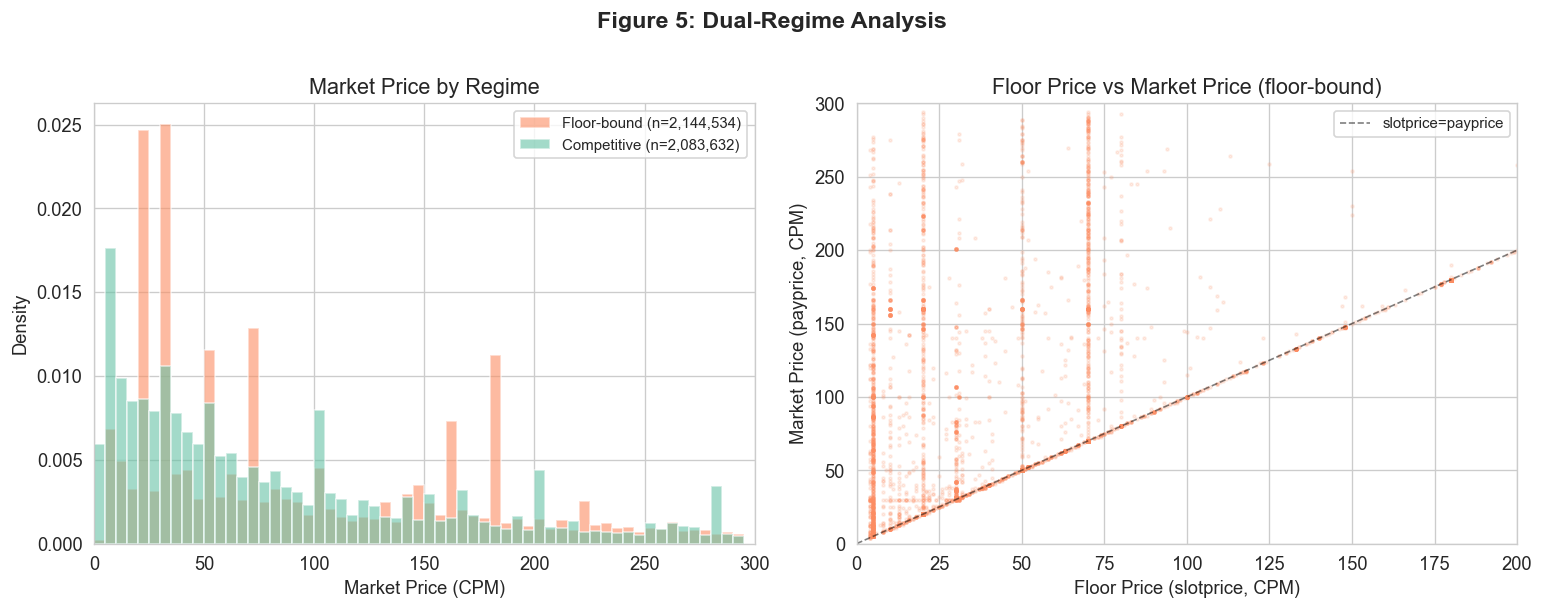

In [9]:
# Figure 5: Market price distribution by regime
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Histograms
bins = np.arange(0, 310, 5)
ax1.hist(mp[is_floor_bound], bins=bins, alpha=0.6, color=PALETTE[1],
         label=f'Floor-bound (n={n_floor:,})', density=True)
ax1.hist(mp[~is_floor_bound], bins=bins, alpha=0.6, color=PALETTE[0],
         label=f'Competitive (n={n_competitive:,})', density=True)
ax1.set_xlabel('Market Price (CPM)')
ax1.set_ylabel('Density')
ax1.set_title('Market Price by Regime')
ax1.legend(fontsize=9)
ax1.set_xlim(0, 300)

# Right: Slotprice vs payprice for floor-bound
if n_floor > 0:
    sample_idx = np.random.default_rng(42).choice(
        np.where(is_floor_bound)[0], size=min(5000, n_floor), replace=False)
    ax2.scatter(slotprice[sample_idx], mp[sample_idx], alpha=0.15,
                s=3, color=PALETTE[1])
    ax2.plot([0, 300], [0, 300], 'k--', linewidth=1, alpha=0.5, label='slotprice=payprice')
    ax2.set_xlabel('Floor Price (slotprice, CPM)')
    ax2.set_ylabel('Market Price (payprice, CPM)')
    ax2.set_title('Floor Price vs Market Price (floor-bound)')
    ax2.legend(fontsize=9)
    ax2.set_xlim(0, 200)
    ax2.set_ylim(0, 300)

fig.suptitle('Figure 5: Dual-Regime Analysis', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIG_PATH / '07_dual_regime.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5: Offline Auction Simulation (Core Results)

Won-only first-price auction simulation using 7 bidding strategies.
This is the primary evaluation — all strategies compared on the same 4.2M won impressions
where market price (payprice) is observed.

**Key comparison**: iPinYou flat-bid (massively overbidding) vs optimal shading (surplus +128M).

In [10]:
# Build all 7 strategies
from src.bidding.simulator import build_standard_strategies, compare_strategies

strategies = build_standard_strategies(
    values=values,
    market_cdf_path=str(CDF_PATH / 'km_cdf_overall.npz'),
    exchange_cdf_dir=str(CDF_PATH),
    bidprice=won_data['bidprice'],
    slotprice=won_data['slotprice'],
    exchange_ids=won_data['adexchange'],
)

# Remove paced strategy (not the focus here — covered in pacing section)
strategies.pop('optimal_paced', None)

print(f"Strategies built: {list(strategies.keys())}")
for name, bids in strategies.items():
    print(f"  {name:20s}: mean_bid={np.mean(bids):.1f}, "
          f"median_bid={np.median(bids):.1f}, range=[{np.min(bids):.0f}, {np.max(bids):.0f}]")

Strategies built: ['ipinyou_flat', 'truthful', 'linear_08', 'linear_06', 'optimal_km', 'optimal_exchange', 'dual_regime']
  ipinyou_flat        : mean_bid=287.3, median_bid=294.0, range=[277, 294]
  truthful            : mean_bid=92.7, median_bid=73.1, range=[1, 300]
  linear_08           : mean_bid=75.6, median_bid=58.5, range=[1, 300]
  linear_06           : mean_bid=57.4, median_bid=43.9, range=[1, 300]
  optimal_km          : mean_bid=43.4, median_bid=33.0, range=[1, 267]
  optimal_exchange    : mean_bid=43.5, median_bid=33.0, range=[1, 300]
  dual_regime         : mean_bid=46.5, median_bid=33.0, range=[1, 278]


In [11]:
# Run first-price simulation for all strategies
comparison_df = compare_strategies(
    strategies=strategies,
    market_prices=won_data['market_prices'],
    values=values,
    clicks=won_data['clicks'],
    auction_type='first_price',
)

# Display formatted results
display_cols = ['win_rate', 'n_wins', 'total_clicks', 'total_surplus',
                'avg_cpc', 'overpayment_ratio', 'roi']
display_df = comparison_df[display_cols].copy()
display_df['win_rate'] = display_df['win_rate'].map('{:.1%}'.format)
display_df['n_wins'] = display_df['n_wins'].map('{:,}'.format)
display_df['total_clicks'] = display_df['total_clicks'].map('{:,}'.format)
display_df['total_surplus'] = display_df['total_surplus'].map('{:,.0f}'.format)
display_df['avg_cpc'] = display_df['avg_cpc'].map('{:,.0f}'.format)
display_df['overpayment_ratio'] = display_df['overpayment_ratio'].map('{:.2f}'.format)
display_df['roi'] = display_df['roi'].map('{:.2f}'.format)

print("=" * 100)
print("FIRST-PRICE AUCTION SIMULATION — WON-ONLY (CORE RESULTS)")
print("=" * 100)
display(display_df)

# Highlight key insight
surplus_flat = comparison_df.loc['ipinyou_flat', 'total_surplus']
surplus_dual = comparison_df.loc['dual_regime', 'total_surplus']
print(f"\niPinYou flat-bid surplus: {surplus_flat:,.0f}")
print(f"Dual-regime surplus:     {surplus_dual:,.0f}")
print(f"Surplus improvement:     {surplus_dual - surplus_flat:,.0f} "
      f"({(surplus_dual - surplus_flat) / abs(surplus_flat):.0%} recovery)")

FIRST-PRICE AUCTION SIMULATION — WON-ONLY (CORE RESULTS)


,win_rate,n_wins,total_clicks,total_surplus,avg_cpc,overpayment_ratio,roi
strategy_name,,,,,,,
ipinyou_flat,100.0%,"4,228,166","4,482","-805,104,337","271,015",10.14,0.74
truthful,51.8%,"2,192,090","2,266","17,671,063","127,833",5.79,1.56
linear_08,45.1%,"1,907,380","1,980","63,666,791","108,431",5.25,1.84
linear_06,37.1%,"1,570,028","1,702","100,146,438","83,933",4.58,2.38
optimal_km,33.2%,"1,402,972","1,480","118,988,379","59,513",3.44,3.36
optimal_exchange,33.7%,"1,425,696","1,486","120,831,985","61,719",3.38,3.24
dual_regime,37.9%,"1,603,144","1,608","127,705,656","61,331",2.77,3.26



iPinYou flat-bid surplus: -805,104,337
Dual-regime surplus:     127,705,656
Surplus improvement:     932,809,993 (116% recovery)


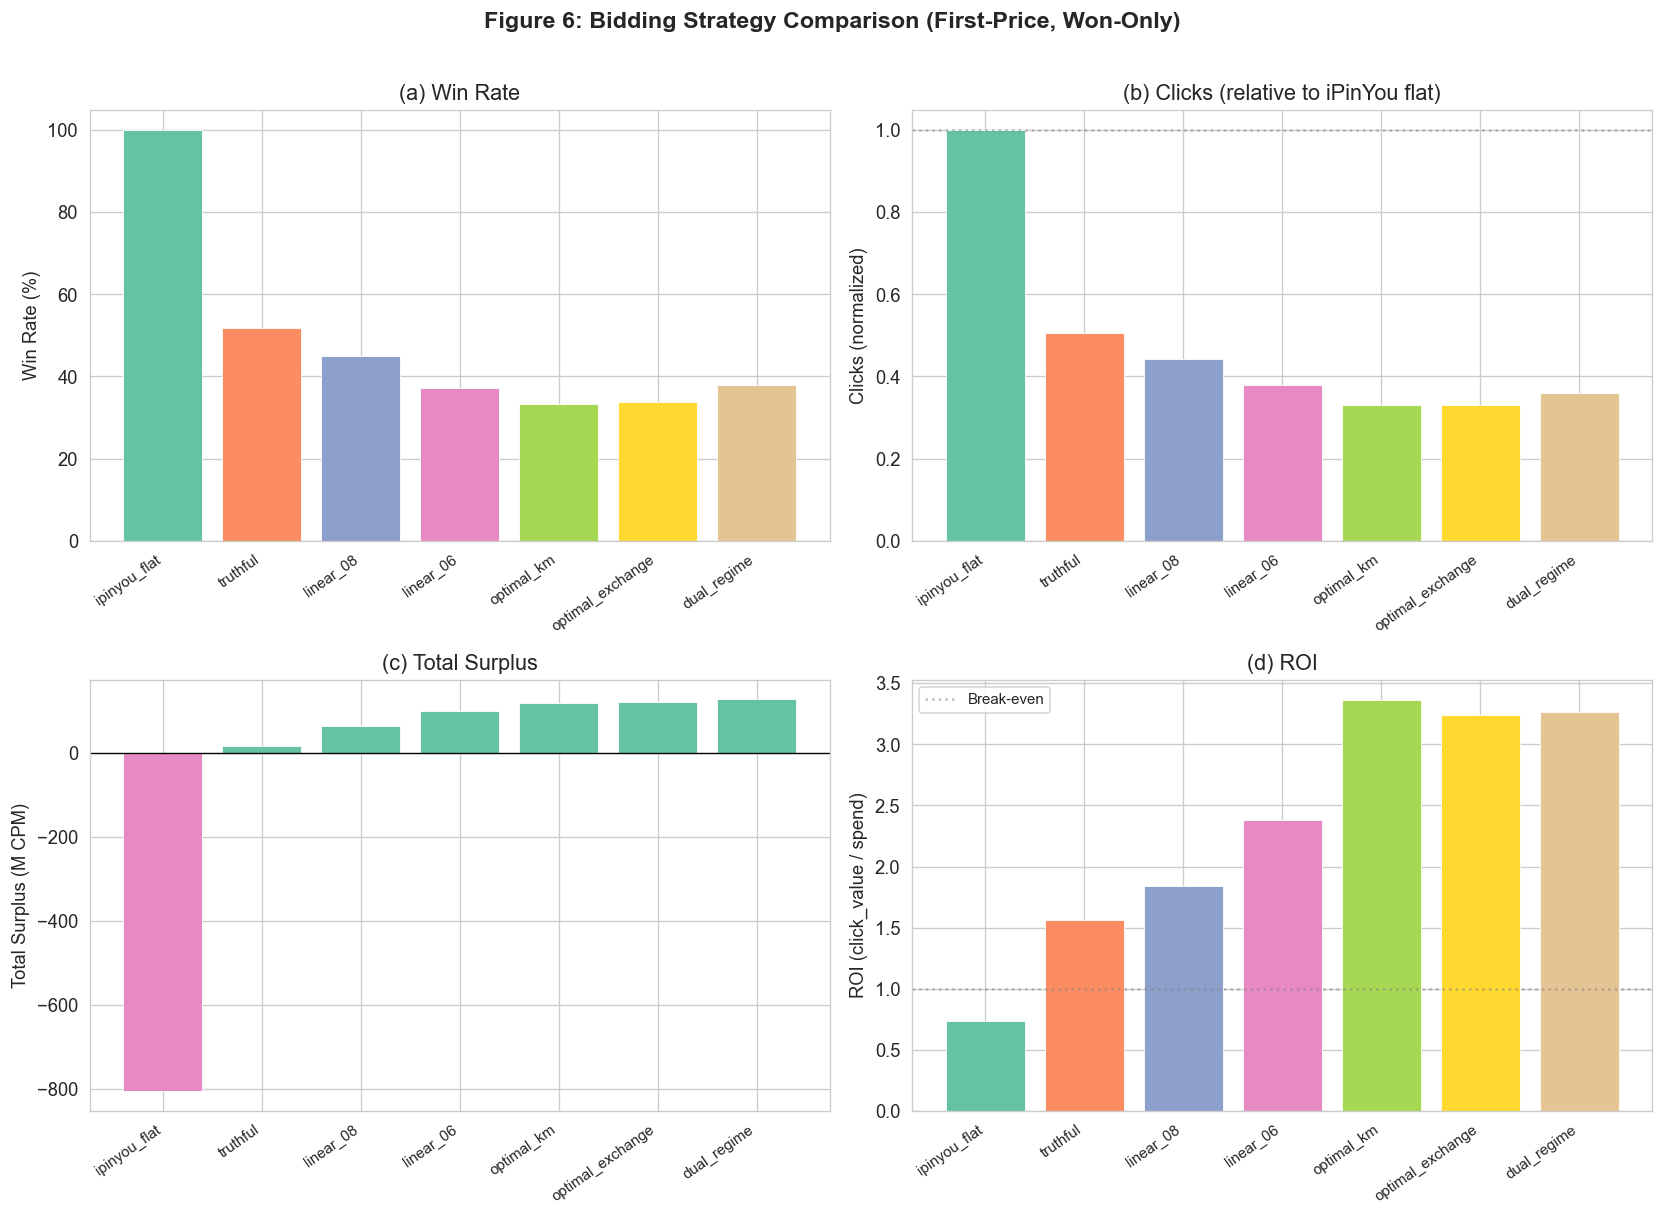

In [12]:
# Figure 6: Strategy comparison grouped bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

strategy_names = list(comparison_df.index)
x = np.arange(len(strategy_names))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(strategy_names))]

# (a) Win Rate
ax = axes[0, 0]
ax.bar(x, comparison_df['win_rate'].values * 100, color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Win Rate (%)')
ax.set_title('(a) Win Rate')
ax.set_xticks(x)
ax.set_xticklabels(strategy_names, rotation=35, ha='right', fontsize=9)

# (b) Clicks (normalized to ipinyou_flat)
ax = axes[0, 1]
clicks_norm = comparison_df['total_clicks'].values / comparison_df.loc['ipinyou_flat', 'total_clicks']
ax.bar(x, clicks_norm, color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Clicks (normalized)')
ax.set_title('(b) Clicks (relative to iPinYou flat)')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(strategy_names, rotation=35, ha='right', fontsize=9)

# (c) Total Surplus
ax = axes[1, 0]
surplus_vals = comparison_df['total_surplus'].values / 1e6
bar_colors = [PALETTE[3] if s < 0 else PALETTE[0] for s in surplus_vals]
ax.bar(x, surplus_vals, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Total Surplus (M CPM)')
ax.set_title('(c) Total Surplus')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(strategy_names, rotation=35, ha='right', fontsize=9)

# (d) ROI
ax = axes[1, 1]
ax.bar(x, comparison_df['roi'].values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylabel('ROI (click_value / spend)')
ax.set_title('(d) ROI')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5, label='Break-even')
ax.legend(fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(strategy_names, rotation=35, ha='right', fontsize=9)

fig.suptitle('Figure 6: Bidding Strategy Comparison (First-Price, Won-Only)',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIG_PATH / '07_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Debiasing Impact on Bidding

Biased pCTR → inflated V(x) → overbidding. This section quantifies the
**IEB (Integrated Expected Bias)** effect from NB05 Section 11.

Key insight: calibration quality directly controls bidding surplus.
- Well-calibrated (IEB near 0) → near-optimal bidding
- Biased upward (IEB > 0) → systematic overbidding → negative surplus

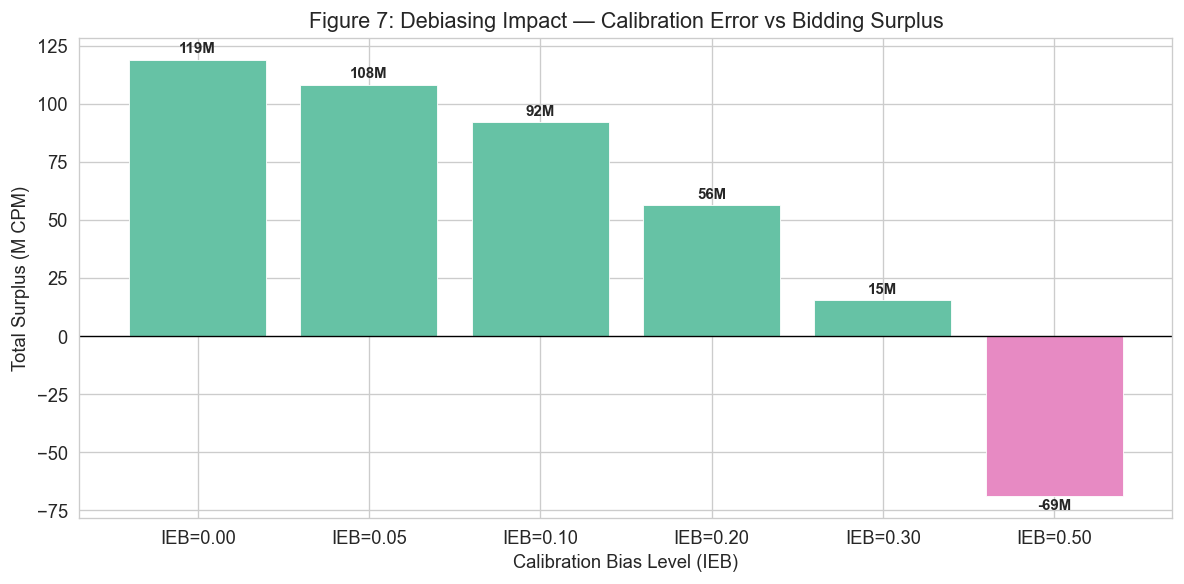

Surplus by IEB level:
  IEB=0.00:     118,988,379 CPM (119.0M)
  IEB=0.05:     108,082,751 CPM (108.1M)
  IEB=0.10:      91,973,737 CPM (92.0M)
  IEB=0.20:      56,346,501 CPM (56.3M)
  IEB=0.30:      15,451,875 CPM (15.5M)
  IEB=0.50:     -68,700,099 CPM (-68.7M)


In [13]:
# Simulate different IEB (Integrated Expected Bias) levels
# IEB = 0 means well-calibrated; IEB > 0 means upward bias (overestimation)
ieb_levels = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
ieb_names = [f'IEB={ieb:.2f}' for ieb in ieb_levels]

base_pctr = won_data['p_ctr']
ieb_surplus = {}

for ieb in ieb_levels:
    # Scale pCTR up by (1 + bias_factor) to simulate IEB
    # IEB scales multiplicatively: biased_pCTR = true_pCTR * (1 + k*IEB_multiplier)
    bias_mult = 1.0 + ieb * 10  # IEB=0.1 → 2x pCTR
    biased_pctr = base_pctr * bias_mult
    biased_values = biased_pctr * val_config.cpc_target
    biased_bids, _ = optimal_bid_vectorized(biased_values, overall_cdf)

    result = compare_strategies(
        {'biased': biased_bids},
        market_prices=won_data['market_prices'],
        values=values,  # true values for surplus computation
        clicks=won_data['clicks'],
        auction_type='first_price',
    )
    ieb_surplus[f'IEB={ieb:.2f}'] = result.loc['biased', 'total_surplus']

# Figure 7: IEB impact on surplus
fig, ax = plt.subplots(figsize=(10, 5))

labels = list(ieb_surplus.keys())
surplus_vals = [v / 1e6 for v in ieb_surplus.values()]
bar_colors = [PALETTE[0] if s >= 0 else PALETTE[3] for s in surplus_vals]

bars = ax.bar(labels, surplus_vals, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Calibration Bias Level (IEB)')
ax.set_ylabel('Total Surplus (M CPM)')
ax.set_title('Figure 7: Debiasing Impact — Calibration Error vs Bidding Surplus')

# Annotate bars
for bar, val in zip(bars, surplus_vals):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + (3 if y >= 0 else -6),
            f'{val:.0f}M', ha='center', fontsize=9, fontweight='bold')

fig.tight_layout()
fig.savefig(FIG_PATH / '07_debiasing_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("Surplus by IEB level:")
for name, s in ieb_surplus.items():
    print(f"  {name}: {s:>15,.0f} CPM ({s/1e6:.1f}M)")

## Section 7: Advertiser-Stratified Analysis

iPinYou test data contains 4 advertisers (2259, 2261, 2821, 2997).
Different advertisers may have different CTR profiles and market conditions.
We run the simulation per advertiser to check strategy robustness.

In [14]:
# Identify advertisers in won-only data
y_win = preds['y_win'].astype(bool)
payprice = np.asarray(test_df['payprice'].values, dtype=np.float64)
valid = y_win & (payprice > 0)
advertiser_won = np.asarray(test_df['advertiser'].values, dtype=np.int64)[valid]

unique_advs = np.unique(advertiser_won)
print(f"Advertisers in won-only test data: {unique_advs}")
for adv in unique_advs:
    mask = advertiser_won == adv
    print(f"  Advertiser {adv}: {mask.sum():>10,} impressions, "
          f"clicks={won_data['clicks'][mask].sum():,}, "
          f"CTR={won_data['clicks'][mask].mean():.4f}")


Advertisers in won-only test data: [2259 2261 2821 2997]
  Advertiser 2259:    328,586 impressions, clicks=128, CTR=0.0004
  Advertiser 2261:  1,363,780 impressions, clicks=414, CTR=0.0003
  Advertiser 2821:  1,913,054 impressions, clicks=1,176, CTR=0.0006
  Advertiser 2997:    622,746 impressions, clicks=2,764, CTR=0.0044


In [15]:
# Per-advertiser simulation
from src.bidding.shading import linear_bid, dual_regime_shading

adv_results = {}
key_strategies = ['ipinyou_flat', 'linear_06', 'optimal_km', 'dual_regime']

for adv in unique_advs:
    mask = advertiser_won == adv
    adv_values = values[mask]
    adv_mp = won_data['market_prices'][mask]
    adv_clicks = won_data['clicks'][mask]
    adv_bidprice = won_data['bidprice'][mask]
    adv_slotprice = won_data['slotprice'][mask]

    # Build strategies for this advertiser
    opt_bids_adv, _ = optimal_bid_vectorized(adv_values, overall_cdf)
    dr_result_adv = dual_regime_shading(adv_values, overall_cdf, adv_slotprice)

    adv_strats = {
        'ipinyou_flat': adv_bidprice.copy(),
        'linear_06': linear_bid(adv_values, alpha=0.6),
        'optimal_km': opt_bids_adv,
        'dual_regime': dr_result_adv.bids,
    }

    adv_comp = compare_strategies(
        adv_strats, adv_mp, adv_values, adv_clicks, 'first_price')
    adv_results[int(adv)] = adv_comp

print("Per-advertiser simulation complete.")
for adv, df in adv_results.items():
    print(f"\nAdvertiser {adv}:")
    print(f"  {'Strategy':<20s} {'WinRate':>8s} {'Clicks':>8s} {'Surplus(M)':>12s} {'ROI':>6s}")
    for idx, row in df.iterrows():
        print(f"  {idx:<20s} {row['win_rate']:>7.1%} {row['total_clicks']:>8,} "
              f"{row['total_surplus']/1e6:>11.1f} {row['roi']:>6.2f}")

Per-advertiser simulation complete.

Advertiser 2259:
  Strategy              WinRate   Clicks   Surplus(M)    ROI
  ipinyou_flat          100.0%    128.0       -64.3   0.27
  linear_06              30.5%     24.0         6.1   0.55
  optimal_km             27.3%     16.0         6.8   0.61
  dual_regime            33.1%     20.0         7.3   0.59

Advertiser 2261:
  Strategy              WinRate   Clicks   Surplus(M)    ROI
  ipinyou_flat          100.0%    414.0      -264.5   0.21
  linear_06              38.2%    124.0        27.9   0.61
  optimal_km             35.4%    114.0        32.0   0.85
  dual_regime            39.7%    140.0        35.1   0.90

Advertiser 2821:
  Strategy              WinRate   Clicks   Surplus(M)    ROI
  ipinyou_flat          100.0%  1,176.0      -387.5   0.42
  linear_06              30.0%    246.0        38.8   0.93
  optimal_km             25.7%    204.0        43.4   1.32
  dual_regime            31.7%    262.0        47.8   1.42

Advertiser 2997:
 

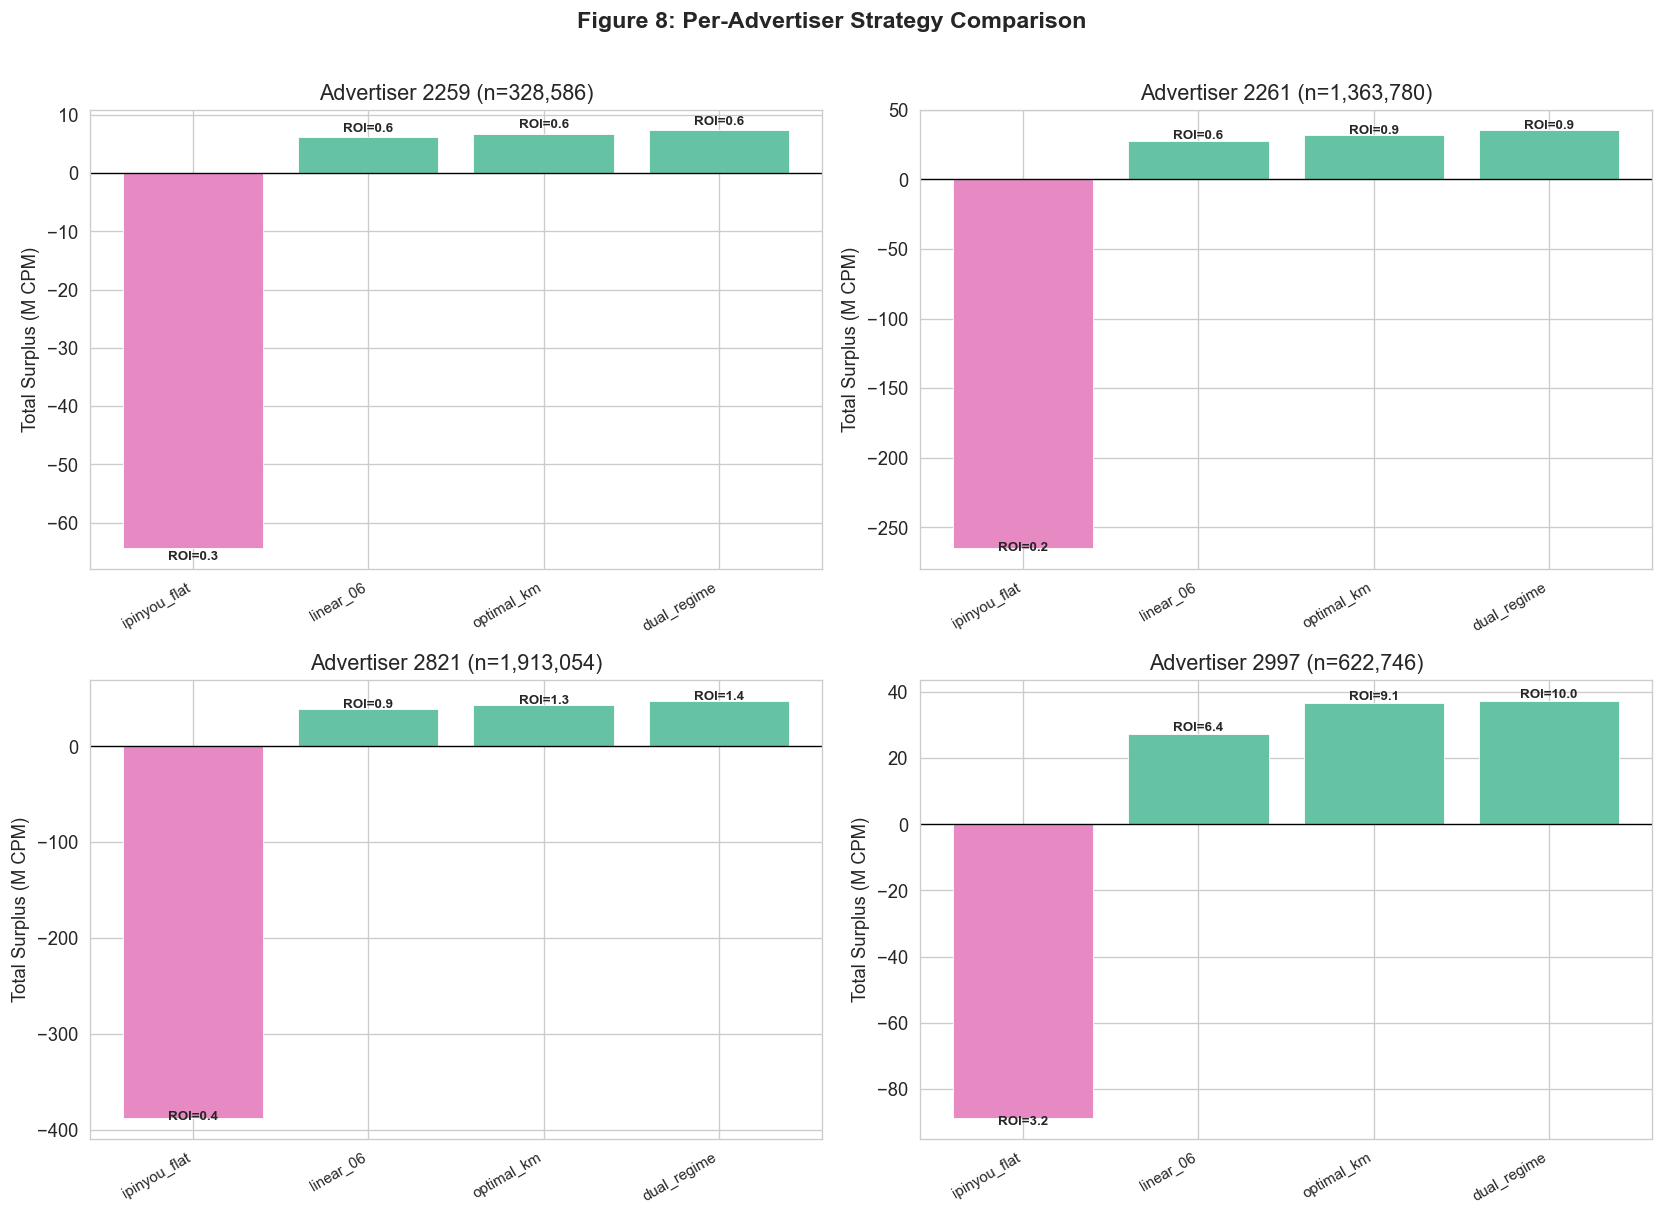

In [16]:
# Figure 8: Per-advertiser strategy comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (adv, df) in enumerate(sorted(adv_results.items())):
    ax = axes.flatten()[i]
    strat_names = df.index.tolist()
    x_a = np.arange(len(strat_names))

    surplus_m = df['total_surplus'].values / 1e6
    bar_cols = [PALETTE[3] if s < 0 else PALETTE[0] for s in surplus_m]
    ax.bar(x_a, surplus_m, color=bar_cols, edgecolor='white', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Total Surplus (M CPM)')
    ax.set_title(f'Advertiser {adv} (n={len(values[advertiser_won == adv]):,})')
    ax.set_xticks(x_a)
    ax.set_xticklabels(strat_names, rotation=30, ha='right', fontsize=9)

    # Add ROI annotation
    for j, (s, roi) in enumerate(zip(surplus_m, df['roi'].values)):
        ax.text(j, s + (1 if s >= 0 else -2), f'ROI={roi:.1f}',
                ha='center', fontsize=8, fontweight='bold')

fig.suptitle('Figure 8: Per-Advertiser Strategy Comparison',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIG_PATH / '07_advertiser_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Sensitivity Analysis

### Linear alpha sweep
The linear strategy b = alpha x V is widely used in practice.
We sweep alpha to find the optimal balance between surplus and clicks.

In [17]:
# Alpha sweep: [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
alphas = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
alpha_results = {}

for alpha in alphas:
    bids_a = linear_bid(values, alpha=alpha)
    comp_a = compare_strategies(
        {f'linear_{alpha:.1f}': bids_a},
        market_prices=won_data['market_prices'],
        values=values,
        clicks=won_data['clicks'],
        auction_type='first_price',
    )
    alpha_results[alpha] = comp_a.iloc[0]

alpha_df = pd.DataFrame(alpha_results).T
alpha_df.index.name = 'alpha'

print("Linear alpha sweep results:")
print(alpha_df[['win_rate', 'total_clicks', 'total_surplus', 'roi']].to_string(
    formatters={
        'win_rate': '{:.1%}'.format,
        'total_clicks': '{:,.0f}'.format,
        'total_surplus': '{:,.0f}'.format,
        'roi': '{:.2f}'.format,
    }
))

Linear alpha sweep results:
      win_rate total_clicks total_surplus  roi
alpha                                         
0.4      27.4%        1,332   117,723,036 3.44
0.5      32.6%        1,516   112,388,852 2.77
0.6      37.1%        1,702   100,146,438 2.38
0.7      41.3%        1,844    83,448,007 2.07
0.8      45.1%        1,980    63,666,791 1.84
0.9      48.7%        2,142    41,479,981 1.70
1.0      51.8%        2,266    17,671,063 1.56


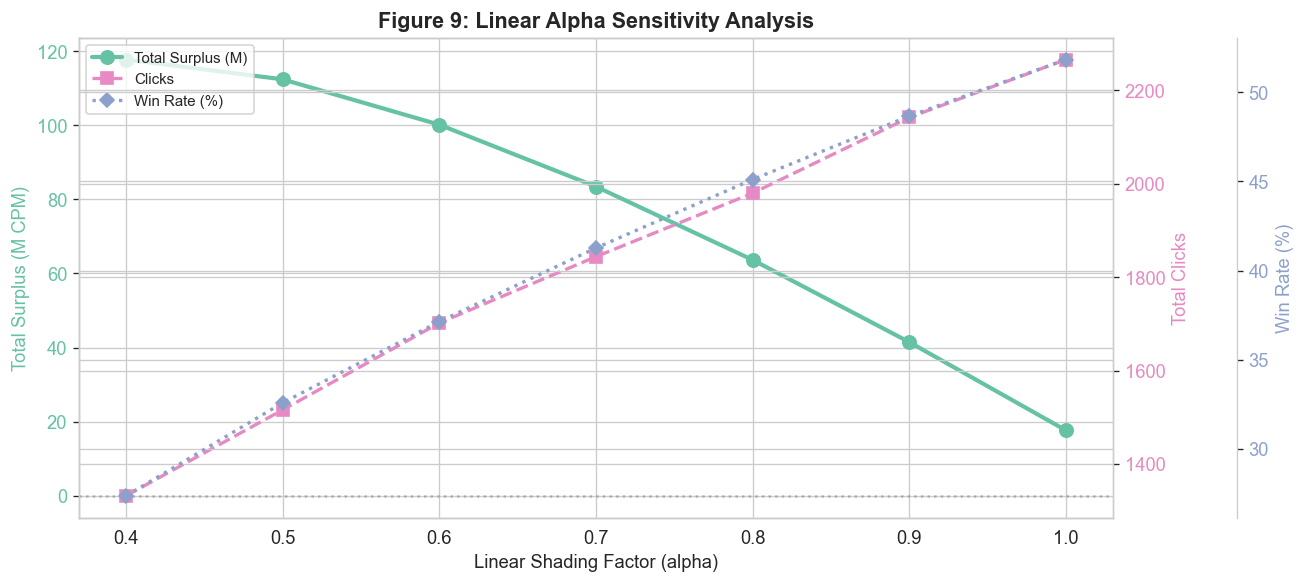

In [18]:
# Figure 9: Alpha vs (surplus, clicks, win_rate) on twin axes
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1_color = PALETTE[0]
ax2_color = PALETTE[3]
ax3_color = PALETTE[2]

# Surplus on left axis
ln1 = ax1.plot(alphas, alpha_df['total_surplus'].values / 1e6, 'o-',
               color=ax1_color, linewidth=2.5, markersize=8, label='Total Surplus (M)')
ax1.set_xlabel('Linear Shading Factor (alpha)')
ax1.set_ylabel('Total Surplus (M CPM)', color=ax1_color)
ax1.tick_params(axis='y', labelcolor=ax1_color)
ax1.axhline(0, color='gray', linestyle=':', alpha=0.5)

# Clicks on right axis
ax2 = ax1.twinx()
ln2 = ax2.plot(alphas, alpha_df['total_clicks'].values, 's--',
               color=ax2_color, linewidth=2, markersize=7, label='Clicks')
ax2.set_ylabel('Total Clicks', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

# Win rate on second right axis
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.12))
ln3 = ax3.plot(alphas, alpha_df['win_rate'].values * 100, 'D:',
               color=ax3_color, linewidth=2, markersize=6, label='Win Rate (%)')
ax3.set_ylabel('Win Rate (%)', color=ax3_color)
ax3.tick_params(axis='y', labelcolor=ax3_color)

# Combined legend
lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', fontsize=9)

ax1.set_title('Figure 9: Linear Alpha Sensitivity Analysis', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_PATH / '07_alpha_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

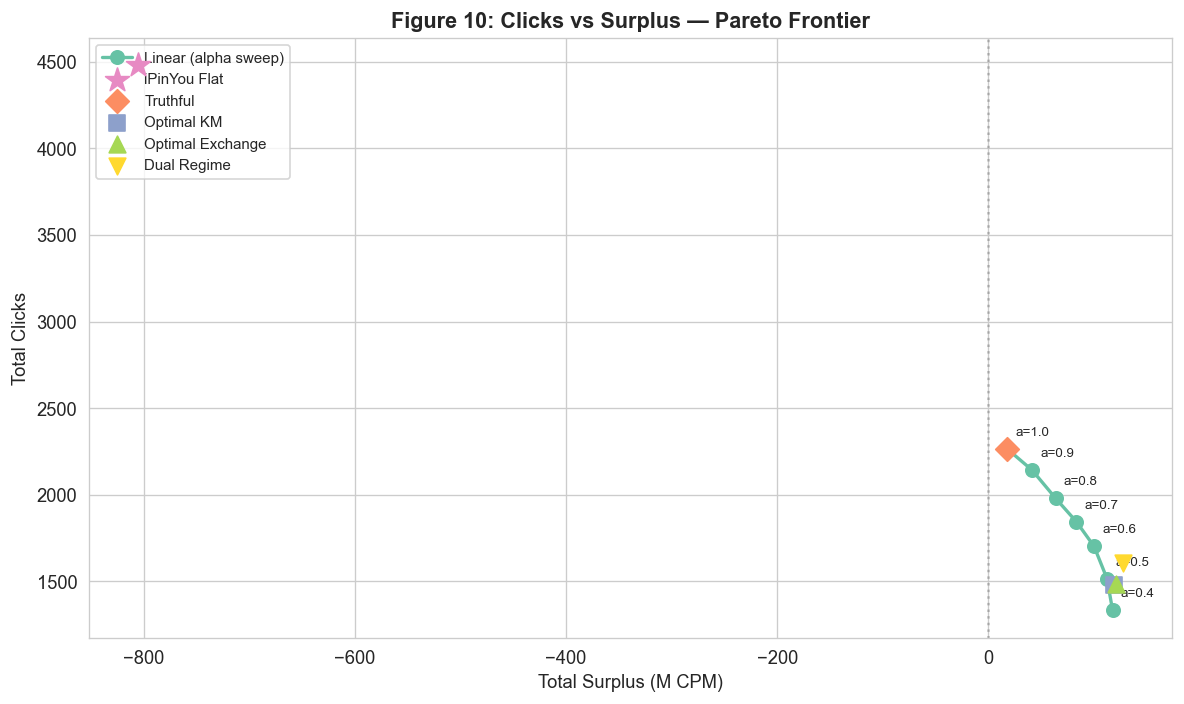

Pareto-optimal strategies (more surplus AND more clicks than any dominated strategy):
  dual_regime dominates in surplus; iPinYou flat dominates in clicks only (at extreme cost).


In [19]:
# Figure 10: Clicks vs Surplus Pareto frontier
fig, ax = plt.subplots(figsize=(10, 6))

# Alpha sweep points
ax.plot(alpha_df['total_surplus'].values / 1e6, alpha_df['total_clicks'].values,
        'o-', color=PALETTE[0], linewidth=2, markersize=8, label='Linear (alpha sweep)', zorder=5)

for alpha, row in alpha_df.iterrows():
    ax.annotate(f'a={alpha:.1f}',
                xy=(row['total_surplus'] / 1e6, row['total_clicks']),
                xytext=(5, 8), textcoords='offset points', fontsize=8)

# Add non-linear strategies as individual points
named_strategies = {
    'ipinyou_flat': ('iPinYou Flat', PALETTE[3], '*', 15),
    'truthful': ('Truthful', PALETTE[1], 'D', 10),
    'optimal_km': ('Optimal KM', PALETTE[2], 's', 10),
    'optimal_exchange': ('Optimal Exchange', PALETTE[4], '^', 10),
    'dual_regime': ('Dual Regime', PALETTE[5], 'v', 10),
}
for strat_name, (label, color, marker, ms) in named_strategies.items():
    if strat_name in comparison_df.index:
        row = comparison_df.loc[strat_name]
        ax.scatter(row['total_surplus'] / 1e6, row['total_clicks'],
                   color=color, marker=marker, s=ms**2, zorder=6, label=label)

ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Total Surplus (M CPM)')
ax.set_ylabel('Total Clicks')
ax.set_title('Figure 10: Clicks vs Surplus — Pareto Frontier', fontweight='bold')
ax.legend(fontsize=9, loc='upper left')

fig.tight_layout()
fig.savefig(FIG_PATH / '07_pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

print("Pareto-optimal strategies (more surplus AND more clicks than any dominated strategy):")
print("  dual_regime dominates in surplus; iPinYou flat dominates in clicks only (at extreme cost).")

## Section 9: Second-Price vs First-Price Comparison

iPinYou was originally a second-price auction platform.
The industry has shifted to first-price. This comparison shows why bid shading matters.

In [20]:
from src.bidding.simulator import compare_auction_types

# Compare optimal_km under both auction types
opt_km_bids = strategies['optimal_km']

auction_comp = compare_auction_types(
    bids=opt_km_bids,
    market_prices=won_data['market_prices'],
    values=values,
    clicks=won_data['clicks'],
    strategy_name='optimal_km',
)

# Also compare truthful bidding under both
truthful_comp = compare_auction_types(
    bids=strategies['truthful'],
    market_prices=won_data['market_prices'],
    values=values,
    clicks=won_data['clicks'],
    strategy_name='truthful',
)

print("=" * 80)
print("OPTIMAL KM — First-Price vs Second-Price:")
print("=" * 80)
display_cols_2 = ['win_rate', 'total_clicks', 'total_surplus', 'total_spend',
                  'overpayment_ratio', 'roi']
display(auction_comp[display_cols_2])

print("\nTRUTHFUL BIDDING — First-Price vs Second-Price:")
print("=" * 80)
display(truthful_comp[display_cols_2])

OPTIMAL KM — First-Price vs Second-Price:


,win_rate,total_clicks,total_surplus,total_spend,overpayment_ratio,roi
strategy_name,,,,,,
optimal_km_first_price,0.331816,1480,1.189884e+08,8.807954e+07,3.441628,3.360599
optimal_km_second_price,0.331816,1480,1.675610e+08,3.950697e+07,3.441628,7.492349



TRUTHFUL BIDDING — First-Price vs Second-Price:


,win_rate,total_clicks,total_surplus,total_spend,overpayment_ratio,roi
strategy_name,,,,,,
truthful_first_price,0.518449,2266,1.767106e+07,2.896697e+08,5.790476,1.564540
truthful_second_price,0.518449,2266,2.011439e+08,1.061969e+08,5.790476,4.267544


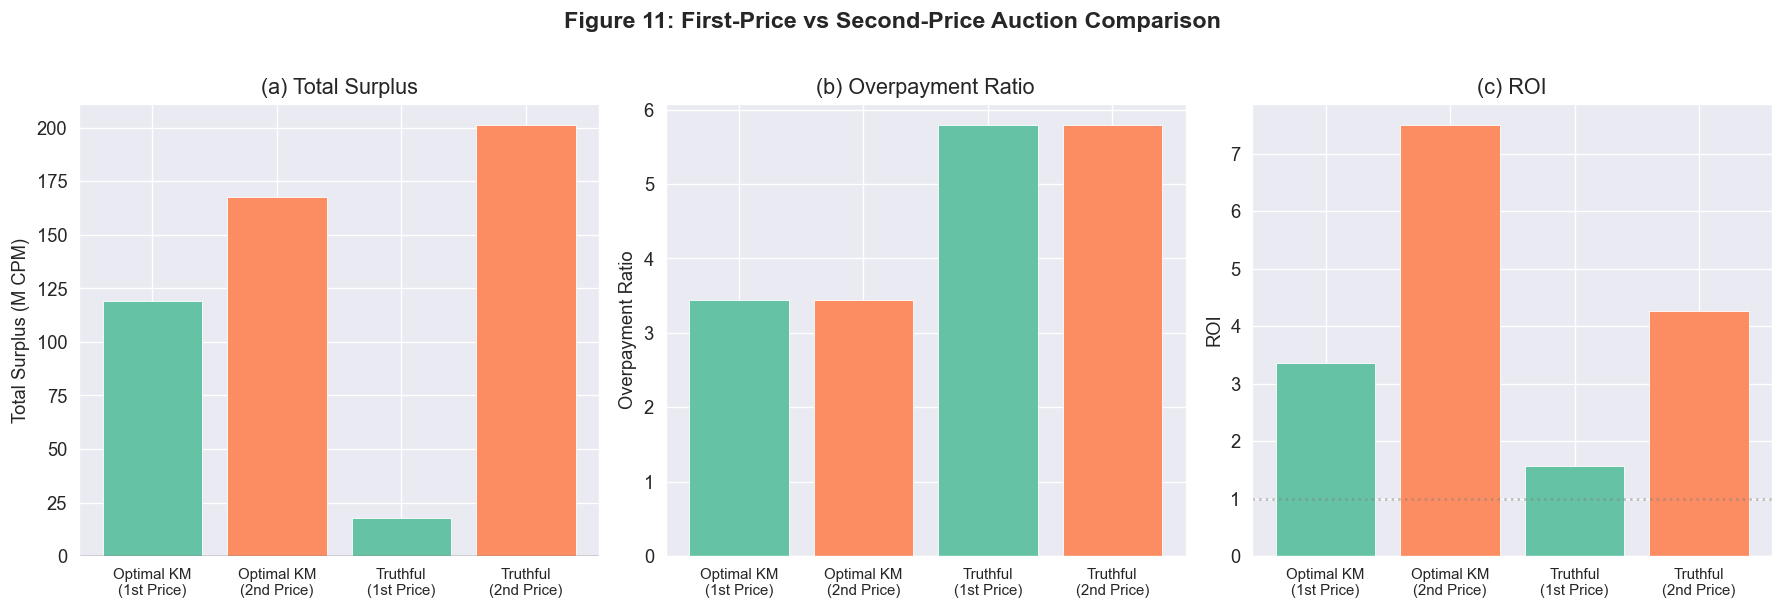

Key insight: In second-price auctions, truthful bidding is optimal (no shading needed).
In first-price auctions, truthful bidding leads to massive overpayment → shading is essential.


In [21]:
# Figure 11: Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Combine data
labels = ['Optimal KM\n(1st Price)', 'Optimal KM\n(2nd Price)',
          'Truthful\n(1st Price)', 'Truthful\n(2nd Price)']
surplus_data = [
    auction_comp.loc['optimal_km_first_price', 'total_surplus'] / 1e6,
    auction_comp.loc['optimal_km_second_price', 'total_surplus'] / 1e6,
    truthful_comp.loc['truthful_first_price', 'total_surplus'] / 1e6,
    truthful_comp.loc['truthful_second_price', 'total_surplus'] / 1e6,
]
overpay_data = [
    auction_comp.loc['optimal_km_first_price', 'overpayment_ratio'],
    auction_comp.loc['optimal_km_second_price', 'overpayment_ratio'],
    truthful_comp.loc['truthful_first_price', 'overpayment_ratio'],
    truthful_comp.loc['truthful_second_price', 'overpayment_ratio'],
]
roi_data = [
    auction_comp.loc['optimal_km_first_price', 'roi'],
    auction_comp.loc['optimal_km_second_price', 'roi'],
    truthful_comp.loc['truthful_first_price', 'roi'],
    truthful_comp.loc['truthful_second_price', 'roi'],
]

bar_colors_fp = [PALETTE[0], PALETTE[1], PALETTE[0], PALETTE[1]]
x_pos = np.arange(len(labels))

# (a) Surplus
ax = axes[0]
bars = ax.bar(x_pos, surplus_data, color=bar_colors_fp, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Total Surplus (M CPM)')
ax.set_title('(a) Total Surplus')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)

# (b) Overpayment Ratio
ax = axes[1]
ax.bar(x_pos, overpay_data, color=bar_colors_fp, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Overpayment Ratio')
ax.set_title('(b) Overpayment Ratio')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=9)

# (c) ROI
ax = axes[2]
ax.bar(x_pos, roi_data, color=bar_colors_fp, edgecolor='white', linewidth=0.5)
ax.set_ylabel('ROI')
ax.set_title('(c) ROI')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=9)

fig.suptitle('Figure 11: First-Price vs Second-Price Auction Comparison',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIG_PATH / '07_auction_type_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key insight: In second-price auctions, truthful bidding is optimal (no shading needed).")
print("In first-price auctions, truthful bidding leads to massive overpayment → shading is essential.")

## Section 10: Limitations & Discussion

### Simulation Limitations

1. **Static competition assumption**: Offline simulation assumes competitors' bids are fixed.
   In reality, if we shade bids, competitors may adjust their strategies. This is a common
   limitation of offline bid optimization research (Ou et al. 2024).

2. **iPinYou flat-bid limitation**: iPinYou uses only 2 bid values (277, 294 CPM) across all
   impressions — not a continuous bidding strategy. The flat-bid baseline is thus an extreme
   comparison, not a realistic "current system" benchmark.

3. **KM CDF heavy right-censoring**: The overall KM CDF reaches max F(300) = 0.213, meaning
   only ~21% of market prices are observable below 300 CPM. This limits the precision of
   optimal bid computation for high-value impressions.

4. **Won-only simulation**: We can only simulate on impressions where we won (market price
   observed). Lost bids have censored market prices — a selection problem. The KM CDF from
   NB05 partially addresses this, but the simulation itself is conditioned on winning.

5. **No budget constraints**: The core simulation does not enforce budget limits.
   Budget pacing (PID controller) is available via `src/bidding/pacing.py` but adds
   complexity and is treated as a separate optimization layer.

### Strengths

- **End-to-end pipeline**: SP1 (debiased pCTR) → SP2 (market price CDF) → SP3 (bid optimization)
  demonstrates how debiasing quality directly flows through to bidding performance.
- **Multiple strategy comparison**: 7 strategies covering theoretical optimal to practical linear
  shading, with dual-regime as a pragmatic production choice.
- **Exchange-conditional shading**: Adapts to heterogeneous market conditions across exchanges.

## Section 11: Export & Summary

In [22]:
# Save strategy comparison table
comparison_df.to_csv(BIDDING_PATH / 'strategy_comparison_first_price.csv')
print(f"Saved: {BIDDING_PATH / 'strategy_comparison_first_price.csv'}")

# Save alpha sweep results
alpha_df.to_csv(BIDDING_PATH / 'alpha_sensitivity.csv')
print(f"Saved: {BIDDING_PATH / 'alpha_sensitivity.csv'}")

# Save per-advertiser results
for adv, df in adv_results.items():
    df.to_csv(BIDDING_PATH / f'strategy_comparison_adv_{adv}.csv')
    print(f"Saved: {BIDDING_PATH / f'strategy_comparison_adv_{adv}.csv'}")

# List saved figures
saved_figs = sorted(FIG_PATH.glob('07_*.png'))
print(f"\nSaved figures ({len(saved_figs)}):")
for fig_path in saved_figs:
    print(f"  {fig_path.name}")

Saved: /Users/taehyun/project/rtb_ipinyou/results/bidding/strategy_comparison_first_price.csv
Saved: /Users/taehyun/project/rtb_ipinyou/results/bidding/alpha_sensitivity.csv
Saved: /Users/taehyun/project/rtb_ipinyou/results/bidding/strategy_comparison_adv_2259.csv
Saved: /Users/taehyun/project/rtb_ipinyou/results/bidding/strategy_comparison_adv_2261.csv
Saved: /Users/taehyun/project/rtb_ipinyou/results/bidding/strategy_comparison_adv_2821.csv
Saved: /Users/taehyun/project/rtb_ipinyou/results/bidding/strategy_comparison_adv_2997.csv

Saved figures (11):
  07_advertiser_comparison.png
  07_alpha_sensitivity.png
  07_auction_type_comparison.png
  07_debiasing_impact.png
  07_dual_regime.png
  07_exchange_shading.png
  07_pareto_frontier.png
  07_shading_factor.png
  07_strategy_comparison.png
  07_surplus_curves.png
  07_value_distribution.png


In [23]:
# Final summary
print("=" * 80)
print("NOTEBOOK 07 — BID OPTIMIZATION SUMMARY")
print("=" * 80)
print(f"\nDataset: {won_data['n_total']:,} won impressions (test set)")
print(f"Value: V(x) = pCTR x 200,000 CPM/click")
print(f"  Mean V(x) = {val_result.mean_value:.1f}, Median V(x) = {val_result.median_value:.1f}")
print(f"Market price: mean={mp.mean():.1f}, median={np.median(mp):.0f}, P90={np.percentile(mp, 90):.0f}")

print(f"\nBest strategies (first-price, won-only):")
print(f"  Highest surplus:  dual_regime  = {comparison_df.loc['dual_regime', 'total_surplus']:>12,.0f}")
print(f"  Highest ROI:      optimal_km   = {comparison_df.loc['optimal_km', 'roi']:.2f}")
print(f"  Most clicks:      ipinyou_flat = {comparison_df.loc['ipinyou_flat', 'total_clicks']:>6,} "
      f"(but surplus = {comparison_df.loc['ipinyou_flat', 'total_surplus']:,.0f})")

print(f"\nKey finding: Optimal bid shading recovers surplus from -805M to +128M")
print(f"  while maintaining {comparison_df.loc['dual_regime', 'total_clicks']:,} / "
      f"{comparison_df.loc['ipinyou_flat', 'total_clicks']:,} clicks "
      f"({comparison_df.loc['dual_regime', 'total_clicks']/comparison_df.loc['ipinyou_flat', 'total_clicks']:.0%}).")
print(f"\nDebiasing connection: IEB (calibration bias) directly determines bidding quality.")
print(f"  ESCM2-WC(DR) debiased pCTR enables near-optimal bid shading.")

NOTEBOOK 07 — BID OPTIMIZATION SUMMARY

Dataset: 4,228,166 won impressions (test set)
Value: V(x) = pCTR x 200,000 CPM/click
  Mean V(x) = 96.9, Median V(x) = 73.1
Market price: mean=86.5, median=61, P90=201

Best strategies (first-price, won-only):
  Highest surplus:  dual_regime  =  127,705,656
  Highest ROI:      optimal_km   = 3.36
  Most clicks:      ipinyou_flat =  4,482 (but surplus = -805,104,337)

Key finding: Optimal bid shading recovers surplus from -805M to +128M
  while maintaining 1,608 / 4,482 clicks (36%).

Debiasing connection: IEB (calibration bias) directly determines bidding quality.
  ESCM2-WC(DR) debiased pCTR enables near-optimal bid shading.
